[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter3_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 3: α-stable distributions

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Stability under summation and the generalised central limit theorem.
- Parameters (α, β, γ, δ), the characteristic function, the S0 and S1 parameterisations (Nolan, 2020).
- Power-law tails, infinite variance, simulation (Chambers–Mallows–Stuck), estimation (McCulloch, maximum likelihood).
- Fits to daily log returns of the BET, S&P 500, DAX and Bitcoin, and the critique of the stable model.
- References: Nolan (2020), *Univariate Stable Distributions*; Borak, Härdle and Weron (2005); Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_3'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- $X \sim S(\alpha, \beta, \gamma, \delta; 1)$ (S1, $\alpha \ne 1$): $\ln E e^{itX} = -\gamma^\alpha|t|^\alpha[1 - i\beta\,\mathrm{sign}(t)\tan(\pi\alpha/2)] + i\delta_1 t$.
- S0: the same law shifted, $\delta_0 = \delta_1 + \beta\gamma\tan(\pi\alpha/2)$; the density is continuous in $\alpha$.
- `scipy.stats.levy_stable` uses S1 by default (`levy_stable.parameterization = 'S1'`).
- Densities: FFT inversion of the characteristic function on a grid (`StableGrid`); simulation: `rstable` (Chambers–Mallows–Stuck); estimation: `mcculloch` and `stable_mle` (S0).
- Returns: daily log returns in %, indices since 2000, Bitcoin since 2014.

In [5]:
START = '2000-01-01'
ASSETS = ['bet', 'sp500', 'dax', 'btc']
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F'}
MODEL_COL = {'Normal': '#CD0000', 'Student-t': '#2E7D32', 'Stable': '#1A3A6E', 'Data': '#B5853F'}
SEED = 2026


def stable_cf(t, alpha, beta, gamma=1.0, delta=0.0, param=0):
    """Characteristic function E exp(itX) of S(alpha, beta, gamma, delta; param), Nolan's S0 (param=0) or S1."""
    t = np.asarray(t, float)
    a = np.abs(gamma * t)
    if alpha != 1:
        tan = np.tan(np.pi * alpha / 2)
        if param == 0:      # -|gt|^a [1 + i b tan(pi a/2) sign(t) (|gt|^(1-a) - 1)], written without 0^(1-a)
            psi = -a ** alpha - 1j * beta * tan * (gamma * t - np.sign(t) * a ** alpha)
        else:               # -|gt|^a [1 - i b tan(pi a/2) sign(t)]
            psi = -a ** alpha * (1 - 1j * beta * tan * np.sign(t))
    else:
        arg = a if param == 0 else np.abs(t)
        lg = np.log(np.where(arg > 0, arg, 1.0))
        psi = -a * (1 + 1j * beta * (2 / np.pi) * np.sign(t) * lg)
    return np.exp(psi + 1j * delta * t)


def s1_to_s0(alpha, beta, gamma, delta1):
    """Location in S0 from the location in S1 (Nolan, 2020): only delta changes."""
    if alpha != 1:
        return delta1 + beta * gamma * np.tan(np.pi * alpha / 2)
    return delta1 + beta * (2 / np.pi) * gamma * np.log(gamma)


def s0_to_s1(alpha, beta, gamma, delta0):
    """Location in S1 from the location in S0."""
    if alpha != 1:
        return delta0 - beta * gamma * np.tan(np.pi * alpha / 2)
    return delta0 - beta * (2 / np.pi) * gamma * np.log(gamma)


class StableGrid:
    """Density and distribution function of the standard S0(alpha, beta, 1, 0) law on a fine grid, by FFT
    inversion of the characteristic function, f(x) = (1/2pi) int phi(t) exp(-itx) dt (Mittnik et al., 1999).
    Grid step h = 0.01 on [-327.68, 327.67]; the power-law tail approximation is used beyond the grid."""

    def __init__(self, alpha, beta, h=0.01, N=2 ** 16):
        k = np.fft.fftfreq(N, d=1.0 / N)                        # 0, 1, ..., N/2-1, -N/2, ..., -1
        dt = 2 * np.pi / (N * h)
        phi = stable_cf(k * dt, alpha, beta, 1.0, 0.0, 0) * np.where(k % 2 == 0, 1.0, -1.0)
        f = np.real(np.fft.fft(phi)) * dt / (2 * np.pi)
        self.alpha, self.beta, self.h = alpha, beta, h
        self.x = (np.arange(N) - N / 2) * h
        self.f = np.maximum(f, 1e-300)
        self.logf = np.log(self.f)
        # tail constant: P(X > x) ~ c_alpha (1 + beta) x^(-alpha), c_alpha = Gamma(alpha) sin(pi alpha / 2) / pi
        from scipy.special import gamma as G
        self.c = 0.0 if alpha >= 2 else G(alpha) * np.sin(np.pi * alpha / 2) / np.pi
        left = self.c * (1 - beta) * abs(self.x[0]) ** (-alpha) if alpha < 2 else 0.0
        right = self.c * (1 + beta) * self.x[-1] ** (-alpha) if alpha < 2 else 0.0
        cells = 0.5 * (self.f[1:] + self.f[:-1]) * h
        self.F = np.clip(left + np.concatenate([[0.0], np.cumsum(cells)]), 0.0, 1.0)           # P(X <= x), from the left
        self.S = np.clip(right + np.concatenate([np.cumsum(cells[::-1])[::-1], [0.0]]), 0.0, 1.0)  # P(X > x), from the right

    def pdf(self, z):
        z = np.asarray(z, float)
        out = np.exp(np.interp(z, self.x, self.logf))
        far = np.abs(z) > self.x[-1]
        if far.any() and self.alpha < 2:
            out[far] = self.alpha * self.c * (1 + np.sign(z[far]) * self.beta) * np.abs(z[far]) ** (-self.alpha - 1)
        return out

    def cdf(self, z):
        z = np.asarray(z, float)
        return np.where(z <= 0, np.interp(z, self.x, self.F), 1 - np.interp(z, self.x, self.S))

    def sf(self, z):
        return 1 - self.cdf(z) if np.ndim(z) == 0 else np.where(np.asarray(z) > 0, np.interp(z, self.x, self.S), 1 - self.cdf(z))

    def ppf(self, p):
        i = np.searchsorted(self.F, 1e-12) if self.F[0] < 1e-12 else 0
        return np.interp(p, self.F[i:], self.x[i:])


def stable_pdf(x, alpha, beta, gamma=1.0, delta=0.0, param=0):
    """Density of S(alpha, beta, gamma, delta; param) on any points x (FFT grid, see StableGrid)."""
    d0 = delta if param == 0 else s1_to_s0(alpha, beta, gamma, delta)
    return StableGrid(alpha, beta).pdf((np.asarray(x, float) - d0) / gamma) / gamma


def rstable(n, alpha, beta=0.0, gamma=1.0, delta=0.0, param=1, rng=None):
    """n draws of S(alpha, beta, gamma, delta) by the Chambers-Mallows-Stuck method.
    V ~ Uniform(-pi/2, pi/2), W ~ Exponential(1), independent; the formula gives S1(alpha, beta, 1, 0)."""
    rng = np.random.default_rng(rng)
    V = rng.uniform(-np.pi / 2, np.pi / 2, n)
    W = rng.exponential(1.0, n)
    if alpha != 1:
        B = np.arctan(beta * np.tan(np.pi * alpha / 2)) / alpha
        S = (1 + beta ** 2 * np.tan(np.pi * alpha / 2) ** 2) ** (1 / (2 * alpha))
        X = (S * np.sin(alpha * (V + B)) / np.cos(V) ** (1 / alpha)
             * (np.cos(V - alpha * (V + B)) / W) ** ((1 - alpha) / alpha))
        Y = gamma * X + (delta if param == 1 else delta - beta * gamma * np.tan(np.pi * alpha / 2))
    else:
        X = (2 / np.pi) * ((np.pi / 2 + beta * V) * np.tan(V)
                           - beta * np.log((np.pi / 2) * W * np.cos(V) / (np.pi / 2 + beta * V)))
        Y = gamma * X + (2 / np.pi) * beta * gamma * np.log(gamma) + (delta if param == 1 else s0_to_s1(1, beta, gamma, delta))
    return Y


def mcculloch(x):
    """McCulloch (1986) quantile estimator of (alpha, beta, gamma, delta0, delta1) from a sample;
    sample quantiles: x_(i) is the (2i - 1)/(2n) quantile, linear interpolation."""
    q05, q25, q50, q75, q95 = np.percentile(np.asarray(x, float), [5, 25, 50, 75, 95], method='hazen')
    return mcculloch_quantiles(q05, q25, q50, q75, q95)


def mcculloch_quantiles(q05, q25, q50, q75, q95):
    """McCulloch (1986) estimates from the 5%, 25%, 50%, 75% and 95% quantiles.
    nu_alpha = (q95 - q05)/(q75 - q25), nu_beta = (q95 + q05 - 2 q50)/(q95 - q05); alpha and beta from
    Tables III-IV, gamma = (q75 - q25)/phi_3(alpha, beta) (Table V), the S0 location from Table VII."""
    from scipy.interpolate import RegularGridInterpolator as RGI
    nu_a_grid = [2.439, 2.5, 2.6, 2.7, 2.8, 3.0, 3.2, 3.5, 4.0, 5.0, 6.0, 8.0, 10.0, 15.0, 25.0]
    nu_b_grid = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
    T3 = [[2.000, 2.000, 2.000, 2.000, 2.000, 2.000, 2.000], [1.916, 1.924, 1.924, 1.924, 1.924, 1.924, 1.924],
          [1.808, 1.813, 1.829, 1.829, 1.829, 1.829, 1.829], [1.729, 1.730, 1.737, 1.745, 1.745, 1.745, 1.745],
          [1.664, 1.663, 1.663, 1.668, 1.676, 1.676, 1.676], [1.563, 1.560, 1.553, 1.548, 1.547, 1.547, 1.547],
          [1.484, 1.480, 1.471, 1.460, 1.448, 1.438, 1.438], [1.391, 1.386, 1.378, 1.364, 1.337, 1.318, 1.318],
          [1.279, 1.273, 1.266, 1.250, 1.210, 1.184, 1.150], [1.128, 1.121, 1.114, 1.101, 1.067, 1.027, 0.973],
          [1.029, 1.021, 1.014, 1.004, 0.974, 0.935, 0.874], [0.896, 0.892, 0.884, 0.883, 0.855, 0.823, 0.769],
          [0.818, 0.812, 0.806, 0.801, 0.780, 0.756, 0.691], [0.698, 0.695, 0.692, 0.689, 0.676, 0.656, 0.597],
          [0.593, 0.590, 0.588, 0.586, 0.579, 0.563, 0.513]]
    T4 = [[0, 2.160, 1.000, 1.000, 1.000, 1.000, 1.000], [0, 1.592, 3.390, 1.000, 1.000, 1.000, 1.000],
          [0, 0.759, 1.800, 1.000, 1.000, 1.000, 1.000], [0, 0.482, 1.048, 1.694, 1.000, 1.000, 1.000],
          [0, 0.360, 0.760, 1.232, 2.229, 1.000, 1.000], [0, 0.253, 0.518, 0.823, 1.575, 1.000, 1.000],
          [0, 0.203, 0.410, 0.632, 1.244, 1.906, 1.000], [0, 0.165, 0.332, 0.499, 0.943, 1.560, 1.000],
          [0, 0.136, 0.271, 0.404, 0.689, 1.230, 2.195], [0, 0.109, 0.216, 0.323, 0.539, 0.827, 1.917],
          [0, 0.096, 0.190, 0.284, 0.472, 0.693, 1.759], [0, 0.082, 0.163, 0.243, 0.412, 0.601, 1.596],
          [0, 0.074, 0.147, 0.220, 0.377, 0.546, 1.482], [0, 0.064, 0.128, 0.191, 0.330, 0.478, 1.362],
          [0, 0.056, 0.112, 0.167, 0.285, 0.428, 1.274]]
    a_grid = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
    b_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
    T5 = [[2.588, 3.073, 4.534, 6.636, 9.144], [2.337, 2.634, 3.542, 4.808, 6.247], [2.189, 2.392, 3.004, 3.844, 4.775],
          [2.098, 2.244, 2.676, 3.265, 3.912], [2.040, 2.149, 2.461, 2.886, 3.356], [2.000, 2.085, 2.311, 2.624, 2.973],
          [1.980, 2.040, 2.205, 2.435, 2.696], [1.965, 2.007, 2.125, 2.294, 2.491], [1.955, 1.984, 2.067, 2.188, 2.333],
          [1.946, 1.967, 2.022, 2.106, 2.211], [1.939, 1.952, 1.988, 2.045, 2.116], [1.933, 1.940, 1.962, 1.997, 2.043],
          [1.927, 1.930, 1.943, 1.961, 1.987], [1.921, 1.922, 1.927, 1.936, 1.947], [1.914, 1.915, 1.916, 1.918, 1.921],
          [1.908, 1.908, 1.908, 1.908, 1.908]]
    T7 = [[0, -0.061, -0.279, -0.659, -1.198], [0, -0.078, -0.272, -0.581, -0.997], [0, -0.089, -0.262, -0.520, -0.853],
          [0, -0.096, -0.250, -0.469, -0.742], [0, -0.099, -0.237, -0.424, -0.652], [0, -0.098, -0.223, -0.380, -0.576],
          [0, -0.095, -0.208, -0.346, -0.508], [0, -0.090, -0.192, -0.310, -0.447], [0, -0.084, -0.173, -0.276, -0.390],
          [0, -0.075, -0.154, -0.241, -0.335], [0, -0.066, -0.134, -0.206, -0.283], [0, -0.056, -0.111, -0.170, -0.232],
          [0, -0.043, -0.088, -0.132, -0.179], [0, -0.030, -0.061, -0.092, -0.123], [0, -0.017, -0.032, -0.049, -0.064],
          [0, 0.000, 0.000, 0.000, 0.000]]
    psi1 = RGI((nu_a_grid, nu_b_grid), np.array(T3), bounds_error=False, fill_value=None)
    psi2 = RGI((nu_a_grid, nu_b_grid), np.array(T4), bounds_error=False, fill_value=None)
    phi3 = RGI((a_grid, b_grid), np.array(T5), bounds_error=False, fill_value=None)
    phi5 = RGI((a_grid, b_grid), np.array(T7), bounds_error=False, fill_value=None)
    nu_a = (q95 - q05) / (q75 - q25)
    nu_b = (q95 + q05 - 2 * q50) / (q95 - q05)
    if nu_a >= 2.439:
        alpha = float(np.clip(psi1([[nu_a, abs(nu_b)]])[0], 0.5, 2.0))
        beta = float(np.clip(np.sign(nu_b) * psi2([[nu_a, abs(nu_b)]])[0], -1.0, 1.0))
    else:
        alpha, beta = 2.0, 0.0
    gamma = float((q75 - q25) / phi3([[alpha, abs(beta)]])[0])
    delta0 = float(q50 + gamma * np.sign(beta) * phi5([[alpha, abs(beta)]])[0])   # zeta in McCulloch (1986)
    delta1 = float(s0_to_s1(alpha, beta, gamma, delta0)) if alpha != 1 else delta0
    return {'alpha': alpha, 'beta': beta, 'gamma': gamma, 'delta0': delta0, 'delta1': delta1,
            'nu_alpha': float(nu_a), 'nu_beta': float(nu_b),
            'q05': float(q05), 'q25': float(q25), 'q50': float(q50), 'q75': float(q75), 'q95': float(q95)}


def stable_nll(p, x):
    """Negative log-likelihood of S0(alpha, beta, gamma, delta0) at p = (alpha, beta, log gamma, delta0)."""
    a, b, lg, d = p
    if not (1.01 <= a <= 1.999 and -0.999 <= b <= 0.999):
        return 1e12
    G = StableGrid(a, b)
    return -np.sum(np.log(G.pdf((x - d) / np.exp(lg)))) + len(x) * lg


def stable_mle(x, start=None, se=True):
    """Maximum likelihood estimate of (alpha, beta, gamma, delta0) in S0 (Nelder-Mead from the McCulloch estimate),
    with standard errors from the numerical Hessian of the log-likelihood; delta1 is the S1 location."""
    from scipy.optimize import minimize
    x = np.asarray(x, float)
    m = start or mcculloch(x)
    p0 = [min(max(m['alpha'], 1.05), 1.98), float(np.clip(m['beta'], -0.95, 0.95)), np.log(m['gamma']), m['delta0']]
    res = minimize(stable_nll, p0, args=(x,), method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-4, 'maxiter': 4000, 'maxfev': 8000})
    a, b, lg, d = res.x
    out = {'alpha': float(a), 'beta': float(b), 'gamma': float(np.exp(lg)), 'delta0': float(d),
           'delta1': float(s0_to_s1(a, b, np.exp(lg), d)), 'loglik': float(-res.fun), 'n': len(x)}
    if se:
        th = np.array([a, b, np.exp(lg), d])

        def f(v):
            return stable_nll([v[0], v[1], np.log(v[2]), v[3]], x)
        steps = np.array([1e-3, 1e-2, 1e-3 * th[2], 1e-3 * th[2]])
        H = np.zeros((4, 4))
        for i in range(4):
            for j in range(i, 4):
                ei, ej = np.eye(4)[i] * steps[i], np.eye(4)[j] * steps[j]
                H[i, j] = H[j, i] = (f(th + ei + ej) - f(th + ei - ej) - f(th - ei + ej) + f(th - ei - ej)) / (4 * steps[i] * steps[j])
        try:
            cov = np.linalg.inv(H)
            sd = np.sqrt(np.clip(np.diag(cov), 0, None))
        except np.linalg.LinAlgError:
            sd = np.full(4, np.nan)
        out.update({'se_alpha': float(sd[0]), 'se_beta': float(sd[1]), 'se_gamma': float(sd[2]), 'se_delta0': float(sd[3])})
    return out


def fit_models(r):
    """Normal, Student-t and stable (ML, S0) fits of one return series, with log-likelihoods and AIC."""
    r = np.asarray(r, float)
    mu, sd = r.mean(), r.std(ddof=0)
    nu, loc, sc = stats.t.fit(r)
    s = stable_mle(r)
    ll_n = float(np.sum(stats.norm.logpdf(r, mu, sd)))
    ll_t = float(np.sum(stats.t.logpdf(r, nu, loc, sc)))
    return {'normal': {'mu': float(mu), 'sigma': float(sd), 'loglik': ll_n, 'aic': 4 - 2 * ll_n},
            't': {'nu': float(nu), 'loc': float(loc), 'scale': float(sc), 'loglik': ll_t, 'aic': 6 - 2 * ll_t},
            'stable': dict(s, aic=8 - 2 * s['loglik']), 'mcculloch': mcculloch(r)}


def model_cdf(x, fit, model):
    """P(R <= x) under a fitted model ('Normal', 'Student-t', 'Stable')."""
    x = np.asarray(x, float)
    if model == 'Normal':
        return stats.norm.cdf(x, fit['normal']['mu'], fit['normal']['sigma'])
    if model == 'Student-t':
        return stats.t.cdf(x, fit['t']['nu'], fit['t']['loc'], fit['t']['scale'])
    s = fit['stable']
    return StableGrid(s['alpha'], s['beta']).cdf((x - s['delta0']) / s['gamma'])


def model_ppf(p, fit, model):
    """Quantile of a fitted model."""
    p = np.asarray(p, float)
    if model == 'Normal':
        return stats.norm.ppf(p, fit['normal']['mu'], fit['normal']['sigma'])
    if model == 'Student-t':
        return stats.t.ppf(p, fit['t']['nu'], fit['t']['loc'], fit['t']['scale'])
    s = fit['stable']
    return s['delta0'] + s['gamma'] * StableGrid(s['alpha'], s['beta']).ppf(p)


def returns(k):
    """Daily log returns in % of one series: indices since 2000, Bitcoin over its full history."""
    return log_returns(k, START if k != 'btc' else None)


def aggregate(r, freq):
    """Sum daily log returns into weekly ('W') or monthly ('ME') log returns."""
    g = r.resample(freq)
    s = g.sum()
    return s[g.count() > 0]

## 1. Densities and parameters

- The effect of α and β; the scale γ; S1 vs S0 near α = 1; the closed-form cases Normal, Cauchy, Lévy.

In [6]:
def fig_density_alpha(save=True):
    """Standard symmetric stable densities S0(alpha, 0, 1, 0) for several alpha, linear and log scale."""
    x = np.linspace(-8, 8, 801)
    alphas = [2.0, 1.7, 1.5, 1.0, 0.7]
    cols = ['#1A3A6E', '#17A2B8', '#2E7D32', '#E67E22', '#CD0000']
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    out = {}
    for a, c in zip(alphas, cols):
        f = StableGrid(a, 0.0).pdf(x) if a >= 1 else stats.levy_stable.pdf(x, a, 0.0)
        lab = f'alpha = {a:g}' + (' (Normal, variance 2)' if a == 2 else ' (Cauchy)' if a == 1 else '')
        axes[0].plot(x, f, color=c, label=lab)
        axes[1].semilogy(x, f, color=c, label='_')
        out[str(a)] = {'f0': float(np.interp(0, x, f)), 'f5': float(np.interp(5, x, f))}
    axes[0].set_xlim(-5, 5)
    axes[0].set_title('Density')
    axes[1].set_title('Density, log scale')
    for ax in axes:
        ax.set_xlabel('x')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_density_alpha')
    return out


def fig_density_beta(save=True):
    """The skewness parameter beta (alpha = 1.3) and the scale gamma (alpha = 1.7), S0 parameterisation."""
    x = np.linspace(-6, 6, 801)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    for b, c in zip([-1, -0.5, 0, 0.5, 1], ['#CD0000', '#E67E22', '#1A3A6E', '#17A2B8', '#2E7D32']):
        axes[0].plot(x, StableGrid(1.3, b).pdf(x), color=c, label=f'beta = {b:g}')
    for g, c in zip([0.5, 1.0, 2.0], ['#8E44AD', '#1A3A6E', '#B5853F']):
        axes[1].plot(x, StableGrid(1.7, 0.0).pdf(x / g) / g, color=c, label=f'gamma = {g:g}')
    axes[0].set_title('alpha = 1.3, gamma = 1: the effect of beta')
    axes[1].set_title('alpha = 1.7, beta = 0: the effect of gamma')
    for ax in axes:
        ax.set_xlabel('x')
        st.legend_outside_bottom(ax, ncol=3, y=-0.18)
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_density_beta')


def fig_s0_s1(save=True):
    """S1 vs S0 with beta = 0.8: in S1 the density runs away as alpha crosses 1; in S0 it moves smoothly."""
    x = np.linspace(-6, 8, 701)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    alphas = [0.8, 0.95, 1.05, 1.2]
    cols = ['#CD0000', '#E67E22', '#17A2B8', '#1A3A6E']
    modes = {}
    for k, (ax, par) in enumerate(zip(axes, ['S1', 'S0'])):
        stats.levy_stable.parameterization = par
        for a, c in zip(alphas, cols):
            f = stats.levy_stable.pdf(x, a, 0.8)
            ax.plot(x, f, color=c, label=f'alpha = {a:g}' if k == 0 else '_')
            modes[f'{par}_{a}'] = float(x[np.argmax(f)])
        ax.set_title(f'{par}: beta = 0.8, gamma = 1, delta = 0')
        ax.set_xlabel('x')
    stats.levy_stable.parameterization = 'S1'
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_s0_s1')
    return modes


def fig_special_cases(save=True):
    """The three stable laws with a closed-form density: Normal, Cauchy and Levy."""
    x = np.linspace(-5, 8, 1301)
    xl = x[x > 0]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(x, stats.norm.pdf(x, 0, 1), color='#1A3A6E', label='Normal: alpha = 2, gamma = 1/sqrt(2) (variance 1)')
    ax.plot(x, stats.cauchy.pdf(x), color='#E67E22', label='Cauchy: alpha = 1, beta = 0, gamma = 1')
    ax.plot(xl, stats.levy.pdf(xl), color='#2E7D32', label='Levy: alpha = 1/2, beta = 1, gamma = 1 (S1)')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    st.legend_outside_bottom(ax, ncol=1, y=-0.15)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_special_cases')

{'2.0': {'f0': 0.28209479177387814, 'f5': 0.0005445710575881734},
 '1.7': {'f0': 0.2840102601824455, 'f5': 0.0045810539871143285},
 '1.5': {'f0': 0.28735282447432997, 'f5': 0.0071118090844462505},
 '1.0': {'f0': 0.31831232437685425, 'f5': 0.012245126403375127},
 '0.7': {'f0': 0.4029241361418608, 'f5': 0.013335610024507812}}

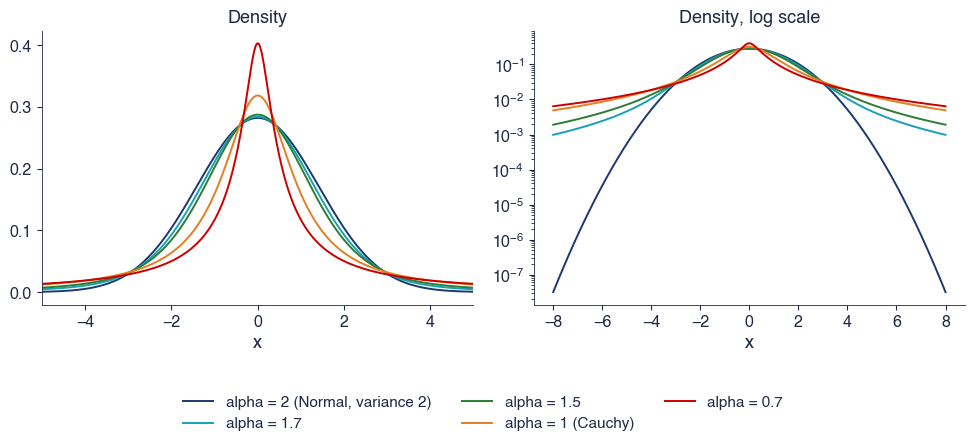

In [7]:
fig_density_alpha(save=False)

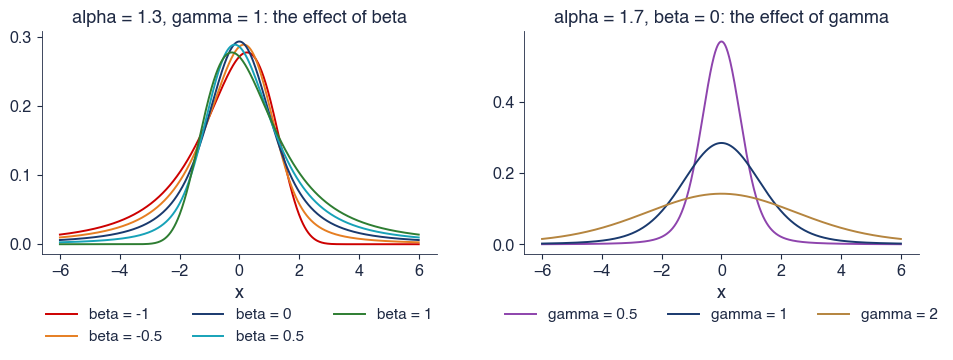

In [8]:
fig_density_beta(save=False)

{'S1_0.8': 1.9800000000000004,
 'S1_0.95': 8.0,
 'S1_1.05': -6.0,
 'S1_1.2': -2.7399999999999998,
 'S0_0.8': -0.47999999999999954,
 'S0_0.95': -0.39999999999999947,
 'S0_1.05': -0.33999999999999986,
 'S0_1.2': -0.2599999999999998}

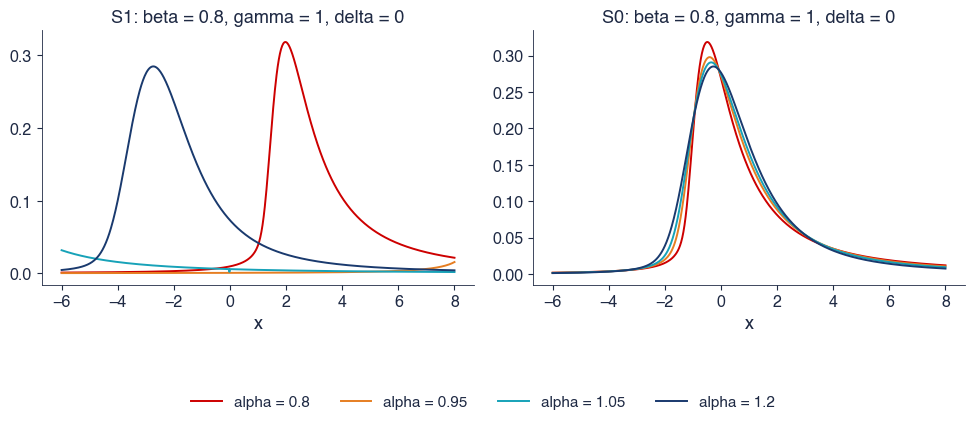

In [9]:
fig_s0_s1(save=False)

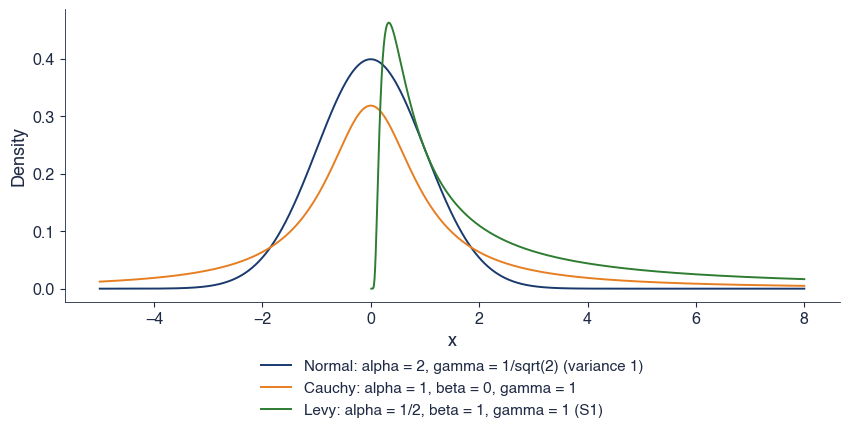

In [10]:
fig_special_cases(save=False)

## 2. Stability and the generalised CLT

- Sums of $n$ i.i.d. stable draws divided by $n^{1/\alpha}$ have the law of one draw.
- Sums of Student-t(1.5) draws (infinite variance) approach a stable law, not the Normal distribution.

In [11]:
def fig_stability_qq(alpha=1.7, n=10, m=50000, save=True):
    """Stability: the sum of n i.i.d. S(alpha, 0, 1, 0) draws divided by n^(1/alpha) has the same law as one draw;
    divided by sqrt(n) it does not. QQ plot of the rescaled sums against single draws."""
    rng = np.random.default_rng(SEED)
    one = rstable(m, alpha, rng=rng)
    sums = rstable(m * n, alpha, rng=rng).reshape(m, n).sum(axis=1)
    p = np.linspace(0.005, 0.995, 199)
    q1 = np.quantile(one, p)
    qa = np.quantile(sums / n ** (1 / alpha), p)
    qs = np.quantile(sums / np.sqrt(n), p)
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(q1, qa, 'o', ms=3.5, color='#1A3A6E', label=f'sum of {n} draws / {n}^(1/alpha)')
    ax.plot(q1, qs, 's', ms=3.0, color='#CD0000', label=f'sum of {n} draws / sqrt({n})')
    lim = [q1.min(), q1.max()]
    ax.plot(lim, lim, color='black', lw=0.8, ls='--', label='45-degree line')
    ax.set_xlabel(f'Quantiles of one draw of S({alpha:g}, 0, 1, 0)')
    ax.set_ylabel('Quantiles of the rescaled sum')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_stability_qq')
    return {'q99_one': float(np.quantile(one, 0.99)), 'q99_alpha': float(np.quantile(sums / n ** (1 / alpha), 0.99)),
            'q99_sqrt': float(np.quantile(sums / np.sqrt(n), 0.99)), 'factor': float(n ** (1 / alpha)), 'sqrtn': float(np.sqrt(n))}


def fig_gclt(nu=1.5, ns=(1, 10, 100), m=40000, save=True):
    """Generalised CLT: sums of n Student-t(nu = 1.5) draws (infinite variance, tail index 1.5) divided by
    n^(1/1.5) approach a symmetric stable law with alpha = 1.5; the Normal law with the same interquartile
    range misses the tails."""
    from scipy.special import gamma as G
    rng = np.random.default_rng(SEED)
    a = nu
    K = G((nu + 1) / 2) / (np.sqrt(nu * np.pi) * G(nu / 2)) * nu ** ((nu + 1) / 2) / nu    # P(T > x) ~ K x^(-nu)
    c = G(a) * np.sin(np.pi * a / 2) / np.pi
    gam = (K / c) ** (1 / a)                                                              # scale of the limit
    x = np.linspace(-15, 15, 601)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    bins = np.linspace(-15, 15, 121)
    out = {'gamma_limit': float(gam)}
    for n_, col in zip(ns, ['#E67E22', '#2E7D32', '#8E44AD']):
        s = rng.standard_t(nu, size=(m, n_)).sum(axis=1) / n_ ** (1 / a)
        h, e = np.histogram(s, bins=bins, density=True)
        ax.semilogy(0.5 * (e[1:] + e[:-1]), np.where(h > 0, h, np.nan), drawstyle='steps-mid', color=col, lw=1.2,
                    label=f'n = {n_}')
        out[f'n{n_}_tail'] = float(np.mean(np.abs(s) > 10))
    f = StableGrid(a, 0.0).pdf(x / gam) / gam
    ax.semilogy(x, f, color='#1A3A6E', lw=2.0, label=f'stable limit S({a:g}, 0, {gam:.2f}, 0)')
    iqr = 2 * gam * StableGrid(a, 0.0).ppf(0.75)
    sd = iqr / (2 * stats.norm.ppf(0.75))
    ax.semilogy(x, stats.norm.pdf(x, 0, sd), color='#CD0000', lw=1.4, ls='--', label='Normal, same interquartile range')
    out['tail_stable'] = float(2 * StableGrid(a, 0.0).sf(np.array([10 / gam]))[0])
    out['tail_normal'] = float(2 * stats.norm.sf(10, 0, sd))
    ax.set_ylim(1e-5, 1)
    ax.set_xlabel('Normalised sum S_n / n^(1/alpha)')
    ax.set_ylabel('Density (log scale)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_gclt')
    return out

{'q99_one': 5.04183750118883,
 'q99_alpha': 5.1476847471438125,
 'q99_sqrt': 6.307354432832318,
 'factor': 3.874675120456131,
 'sqrtn': 3.1622776601683795}

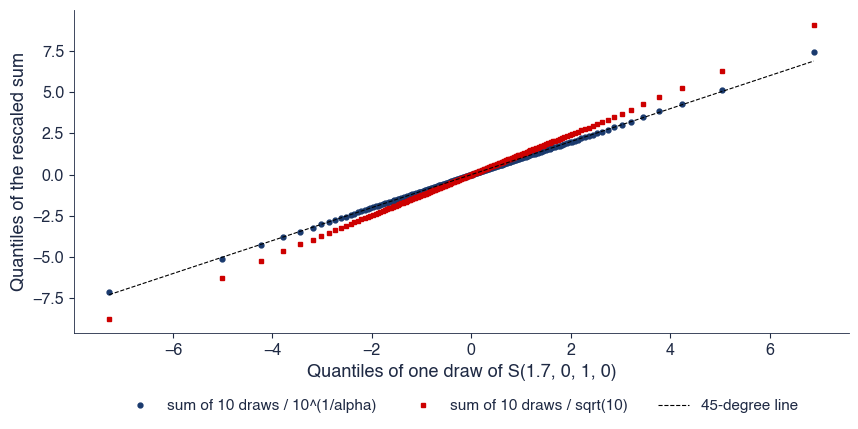

In [12]:
fig_stability_qq(save=False)

{'gamma_limit': 1.5288785161328688,
 'n1_tail': 0.023675,
 'n10_tail': 0.026725,
 'n100_tail': 0.0273,
 'tail_stable': 0.02636959553670383,
 'tail_normal': 5.2675413207888e-06}

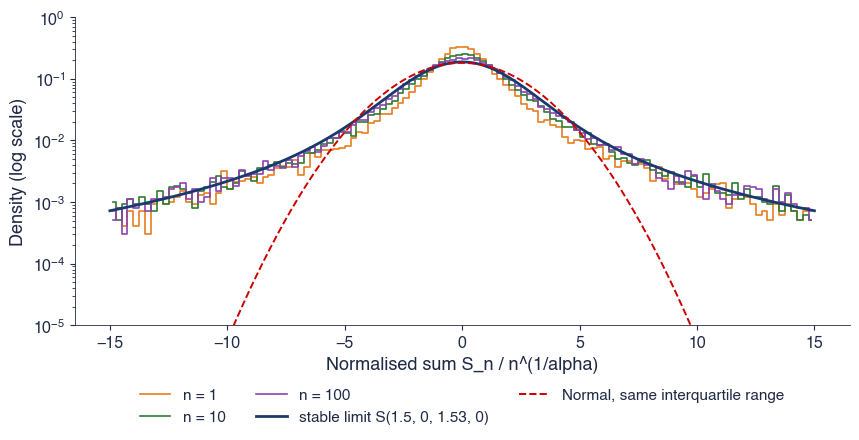

In [13]:
fig_gclt(save=False)

## 3. Tails and moments

- $P(X > x) \sim \gamma^\alpha c_\alpha (1 + \beta) x^{-\alpha}$, $c_\alpha = \Gamma(\alpha)\sin(\pi\alpha/2)/\pi$.
- $E|X|^p < \infty$ only for $p < \alpha$: the sample variance of a stable sample does not settle.

In [14]:
def fig_tails_loglog(save=True):
    """Right-tail probability P(X > x) on log-log axes: a straight line of slope -alpha for alpha < 2."""
    x = np.logspace(0, 2.2, 60)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    for a, c in zip([2.0, 1.9, 1.7, 1.5], ['#1A3A6E', '#17A2B8', '#2E7D32', '#CD0000']):
        G = StableGrid(a, 0.0)
        sf = G.sf(x) if a < 2 else stats.norm.sf(x, 0, np.sqrt(2))
        ok = sf > 1e-12
        ax.loglog(x[ok], sf[ok], color=c, label=f'alpha = {a:g}' + (' (Normal)' if a == 2 else ''))
        if a < 2:
            ax.loglog(x, G.c * x ** (-a), color=c, ls=':', lw=1.0, label='_')
            out[str(a)] = {'sf10': float(G.sf(np.array([10.0]))[0]), 'sf20': float(G.sf(np.array([20.0]))[0]), 'c': float(G.c)}
    out['2.0'] = {'sf10': float(stats.norm.sf(10, 0, np.sqrt(2)))}
    ax.set_ylim(1e-8, 1)
    ax.set_xlabel('x (log scale)')
    ax.set_ylabel('P(X > x) (log scale)')
    ax.text(30, 2e-2, 'dotted: c x^(-alpha)', color='black', fontsize=11)
    st.legend_outside_bottom(ax, ncol=4, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_tails_loglog')
    return out


def tail_table(alpha=1.7, ks=(2, 3, 5, 10)):
    """P(|X| > k) for the Normal law with the same scale (S(2, 0, 1, 0) = N(0, 2)) and for S0(alpha, 0, 1, 0)."""
    G = StableGrid(alpha, 0.0)
    return {str(k): {'normal': float(2 * stats.norm.sf(k, 0, np.sqrt(2))), 'stable': float(2 * G.sf(np.array([float(k)]))[0])} for k in ks}


def fig_running_variance(n=20000, alpha=1.7, save=True):
    """Running sample variance of n draws: Normal (it settles at 2) vs stable alpha = 1.7 (it keeps jumping)."""
    rng = np.random.default_rng(SEED)
    k = np.arange(1, n + 1)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    z = rstable(n, 2.0, 0.0, 1.0, 0.0, rng=rng)
    v = np.cumsum(z ** 2) / k - (np.cumsum(z) / k) ** 2
    ax.plot(k[9:], v[9:], color='#1A3A6E', label='Normal = S(2, 0, 1, 0), true variance 2')
    for i, c in enumerate(['#CD0000', '#E67E22', '#2E7D32']):
        x = rstable(n, alpha, 0.0, 1.0, 0.0, rng=rng)
        v = np.cumsum(x ** 2) / k - (np.cumsum(x) / k) ** 2
        ax.plot(k[9:], v[9:], color=c, lw=1.1, label=f'stable alpha = {alpha:g}, path {i + 1}')
        out[f'path{i + 1}'] = {'v1000': float(v[999]), 'vend': float(v[-1])}
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Sample size n (log scale)')
    ax.set_ylabel('Sample variance (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_running_var_sim')
    return out

{'1.9': {'sf10': 0.0006442991119450595,
  'sf20': 0.00016500753285367037,
  'c': 0.0478907802501024},
 '1.7': {'sf10': 0.002792252791267976,
  'sf20': 0.0008278669691941487,
  'c': 0.1313070782551674},
 '1.5': {'sf10': 0.006672707555755145,
  'sf20': 0.002302717676943248,
  'c': 0.19947114020071635},
 '2.0': {'sf10': 7.687298972140177e-13}}

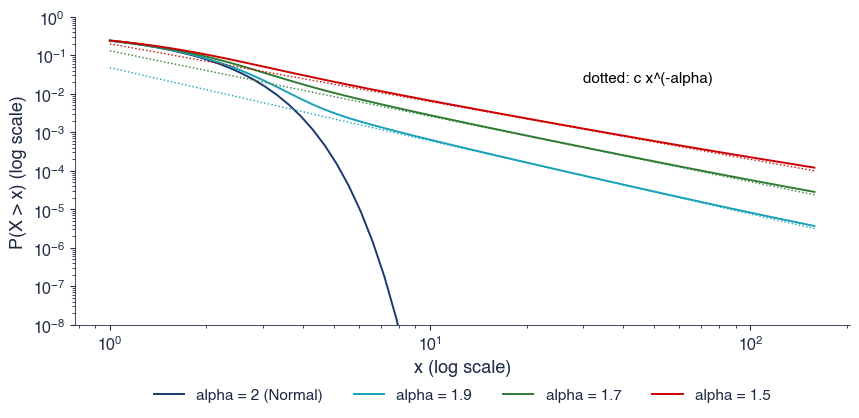

In [15]:
fig_tails_loglog(save=False)

In [16]:
pd.DataFrame(tail_table()).T

,normal,stable
2,1.572992e-01,0.185862
3,3.389485e-02,0.072484
5,4.069520e-04,0.021334
10,1.537460e-12,0.005585


{'path1': {'v1000': 9.052487526503988, 'vend': 10.359706404840285},
 'path2': {'v1000': 4.16347748482521, 'vend': 6.5558903812109754},
 'path3': {'v1000': 6.036120045682181, 'vend': 20.230093234104633}}

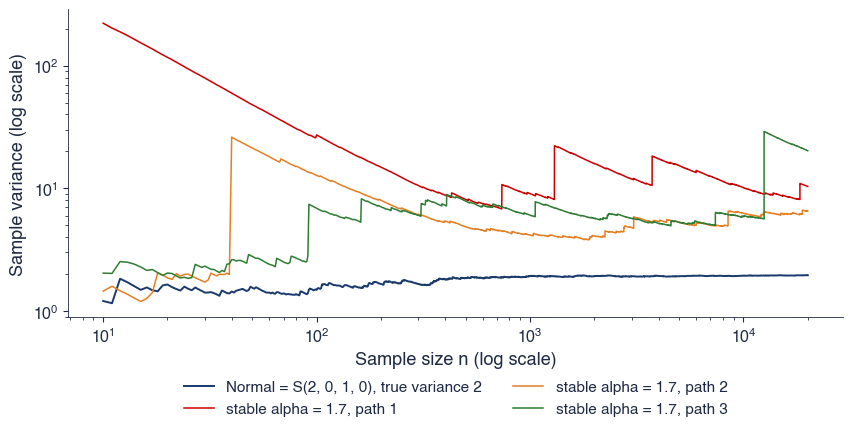

In [17]:
fig_running_variance(save=False)

## 4. Simulation: Chambers–Mallows–Stuck

- 100,000 draws of $S(1.5, 0.5, 1, 0; 1)$ against the exact density; a two-sample KS test against `levy_stable.rvs`.

In [18]:
def fig_cms(alpha=1.5, beta=0.5, n=100000, save=True):
    """Chambers-Mallows-Stuck draws of S1(1.5, 0.5, 1, 0) against the exact density; the same law from scipy."""
    rng = np.random.default_rng(SEED)
    x = rstable(n, alpha, beta, rng=rng)
    y = stats.levy_stable.rvs(alpha, beta, size=n, random_state=SEED)
    grid = np.linspace(-8, 8, 801)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    bins = np.linspace(-8, 8, 161)
    ax.hist(x[(x > -8) & (x < 8)], bins=bins, density=False, weights=np.full(((x > -8) & (x < 8)).sum(), 1 / (n * 0.1)),
            color='#17A2B8', alpha=0.55, label='CMS draws (histogram)')
    ax.plot(grid, stable_pdf(grid, alpha, beta, 1.0, 0.0, param=1), color='#1A3A6E', lw=1.8, label='exact density S1(1.5, 0.5, 1, 0)')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_cms')
    ks = stats.ks_2samp(x, y)
    return {'ks_stat': float(ks.statistic), 'ks_p': float(ks.pvalue), 'mean_med': float(np.median(x)),
            'q01': float(np.quantile(x, 0.01)), 'q99': float(np.quantile(x, 0.99)),
            'q01_exact': float(StableGrid(alpha, beta).ppf(0.01) + beta * np.tan(np.pi * alpha / 2)),
            'q99_exact': float(StableGrid(alpha, beta).ppf(0.99) + beta * np.tan(np.pi * alpha / 2))}

{'ks_stat': 0.0043500000000000205,
 'ks_p': 0.29957136256174766,
 'mean_med': -0.3748034589376169,
 'q01': -5.470906721435063,
 'q99': 9.52214599927251,
 'q01_exact': -5.400260888583676,
 'q99_exact': 9.763933750491233}

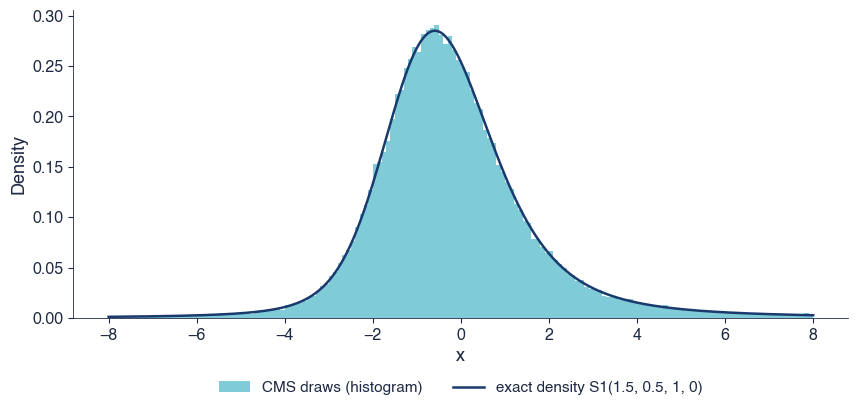

In [19]:
fig_cms(save=False)

## 5. Estimation: McCulloch and maximum likelihood

- McCulloch (1986): $\nu_\alpha = (q_{0.95} - q_{0.05})/(q_{0.75} - q_{0.25})$ and $\nu_\beta$, then the tables.
- ML in S0 with an FFT density, standard errors from the numerical Hessian.
- Monte Carlo: 200 samples of $S(1.7, 0, 1, 0)$ for $n = 500$ and $n = 2500$ (a few minutes).

In [20]:
def fig_mcculloch_map(real=None, save=True):
    """McCulloch's Table III for nu_beta = 0: alpha as a function of nu_alpha = (q95 - q05)/(q75 - q25)."""
    nu = [2.439, 2.5, 2.6, 2.7, 2.8, 3.0, 3.2, 3.5, 4.0, 5.0, 6.0]
    al = [2.000, 1.916, 1.808, 1.729, 1.664, 1.563, 1.484, 1.391, 1.279, 1.128, 1.029]
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.plot(nu, al, 'o-', color='#1A3A6E', label='McCulloch (1986), Table III, nu_beta = 0')
    if real:
        for k, (va, a) in real.items():
            ax.plot(va, a, '*', ms=13, color=COLORS[k], label=LABELS[k], ls='none')
    ax.set_xlabel('nu_alpha = (q95 - q05) / (q75 - q25)')
    ax.set_ylabel('alpha')
    st.legend_outside_bottom(ax, ncol=5, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_mcculloch_map')


def estimator_mc(alpha=1.7, beta=0.0, ns=(500, 2500), reps=200):
    """Monte Carlo: sampling distribution of alpha-hat (McCulloch and ML) for S(1.7, 0, 1, 0) samples."""
    rng = np.random.default_rng(SEED)
    out = {}
    for n in ns:
        mc, ml = [], []
        for _ in range(reps):
            x = rstable(n, alpha, beta, rng=rng)
            m = mcculloch(x)
            mc.append(m['alpha'])
            ml.append(stable_mle(x, start=m, se=False)['alpha'])
        out[n] = {'mcculloch': np.array(mc), 'ml': np.array(ml)}
    return out


def fig_estimator_mc(res, alpha=1.7, save=True):
    """Box plots of alpha-hat from the Monte Carlo study."""
    fig, ax = plt.subplots(figsize=(10, 3.9))
    data, labels, cols = [], [], []
    for n, r in res.items():
        for k, name, c in [('mcculloch', 'McCulloch', '#E67E22'), ('ml', 'ML', '#1A3A6E')]:
            data.append(r[k])
            labels.append(f'{name}\nn = {n}')
            cols.append(c)
    bp = ax.boxplot(data, patch_artist=True, widths=0.55)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    for patch, c in zip(bp['boxes'], cols):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
        patch.set_edgecolor('black')
    for el in ('whiskers', 'caps', 'medians'):
        for line in bp[el]:
            line.set_color('black')
    for fl in bp['fliers']:
        fl.set_markeredgecolor('#CD0000')
    ax.axhline(alpha, color='#CD0000', ls='--', lw=1.0, label=f'true alpha = {alpha:g}')
    ax.set_ylabel('alpha-hat')
    st.legend_outside_bottom(ax, ncol=1, y=-0.22)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_estimators_mc')
    return {str(n): {k: {'mean': float(v.mean()), 'sd': float(v.std(ddof=1))} for k, v in r.items()} for n, r in res.items()}

BET {'nu_alpha': 3.425, 'nu_beta': -0.006, 'alpha': 1.414, 'beta': -0.011, 'gamma': 0.6, 'delta0': 0.079}
S&P 500 {'nu_alpha': 3.338, 'nu_beta': -0.081, 'alpha': 1.438, 'beta': -0.151, 'gamma': 0.543, 'delta0': 0.087}
DAX {'nu_alpha': 3.285, 'nu_beta': -0.059, 'alpha': 1.455, 'beta': -0.113, 'gamma': 0.681, 'delta0': 0.097}
Bitcoin {'nu_alpha': 3.803, 'nu_beta': -0.018, 'alpha': 1.322, 'beta': -0.027, 'gamma': 1.437, 'delta0': 0.117}


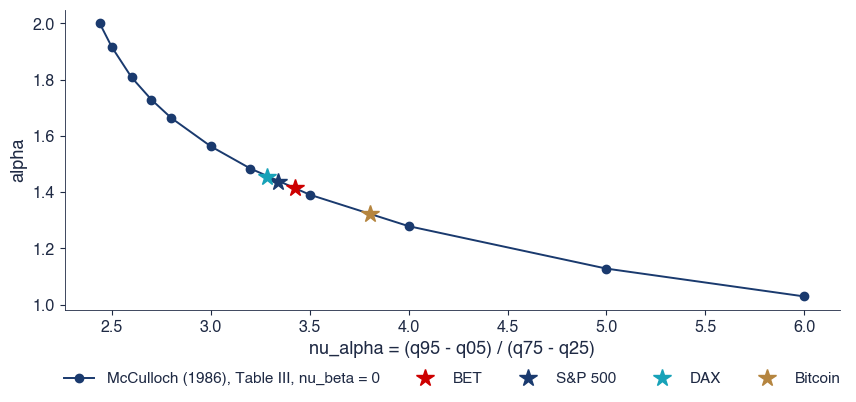

In [21]:
real = {}
for k in ASSETS:
    m = mcculloch(returns(k).values)
    real[k] = (m['nu_alpha'], m['alpha'])
    print(LABELS[k], {c: round(m[c], 3) for c in ['nu_alpha', 'nu_beta', 'alpha', 'beta', 'gamma', 'delta0']})
fig_mcculloch_map(real, save=False)

{'500': {'mcculloch': {'mean': 1.7088643724029868, 'sd': 0.10650198970919846},
  'ml': {'mean': 1.6986942783412353, 'sd': 0.061135517331361695}},
 '2500': {'mcculloch': {'mean': 1.707131926184892, 'sd': 0.04622643280387229},
  'ml': {'mean': 1.7037175856962685, 'sd': 0.029778907013310082}}}

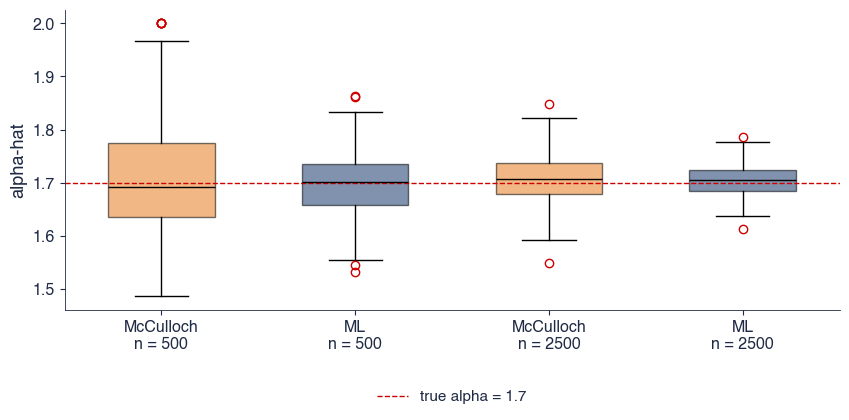

In [22]:
fig_estimator_mc(estimator_mc(), save=False)

## 6. Fitting real returns

- Stable (ML), Student-t and Normal fits; densities on a log scale, QQ plots, the left tail.
- Observed vs expected numbers of large daily losses; VaR 1% and VaR 0.1% of the data and of each model.

In [23]:
def fit_all(names=ASSETS):
    """Normal, Student-t, McCulloch and ML stable fits of the daily log returns of each series."""
    out = {}
    for k in names:
        r = returns(k)
        f = fit_models(r.values)
        f['n'] = len(r)
        f['first'] = r.index[0].date().isoformat()
        f['last'] = r.index[-1].date().isoformat()
        f['min'] = float(r.min())
        f['min_date'] = r.idxmin().date().isoformat()
        f['sd'] = float(r.std())
        out[k] = f
    return out


def fits_table(fits):
    rows = {}
    for k, f in fits.items():
        s, m, t = f['stable'], f['mcculloch'], f['t']
        rows[LABELS[k]] = {'n': f['n'], 'alpha_mcc': m['alpha'], 'beta_mcc': m['beta'], 'gamma_mcc': m['gamma'],
                           'alpha_ml': s['alpha'], 'se_alpha': s['se_alpha'], 'beta_ml': s['beta'], 'se_beta': s['se_beta'],
                           'gamma_ml': s['gamma'], 'delta0_ml': s['delta0'], 'delta1_ml': s['delta1'],
                           't_nu': t['nu'], 't_scale': t['scale'], 'sd': f['normal']['sigma'],
                           'aic_normal': f['normal']['aic'], 'aic_t': t['aic'], 'aic_stable': s['aic']}
    return pd.DataFrame(rows).T


def fig_fit_density(fits, save=True):
    """Empirical density (log scale) of daily log returns vs the fitted Normal, Student-t and stable densities."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 6.4))
    for ax, k in zip(axes.flat, ASSETS):
        r = returns(k).values
        f = fits[k]
        lo, hi = np.quantile(r, 0.0005), np.quantile(r, 0.9995)
        bins = np.linspace(lo, hi, 70)
        h, e = np.histogram(r, bins=bins, density=True)
        mid = 0.5 * (e[1:] + e[:-1])
        ax.semilogy(mid[h > 0], h[h > 0], 'o', ms=3, color=MODEL_COL['Data'], label='Data (histogram)')
        x = np.linspace(lo, hi, 400)
        s = f['stable']
        ax.semilogy(x, stats.norm.pdf(x, f['normal']['mu'], f['normal']['sigma']), color=MODEL_COL['Normal'], label='Normal')
        ax.semilogy(x, stats.t.pdf(x, f['t']['nu'], f['t']['loc'], f['t']['scale']), color=MODEL_COL['Student-t'], label='Student-t')
        ax.semilogy(x, stable_pdf(x, s['alpha'], s['beta'], s['gamma'], s['delta0']), color=MODEL_COL['Stable'], label='Stable (ML)')
        ax.set_ylim(max(h[h > 0].min() / 3, 1e-4), h.max() * 3)
        ax.set_title(f"{LABELS[k]}: alpha-hat = {s['alpha']:.2f}")
        ax.set_xlabel('Daily log return (%)')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.02, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_fit_density')


def fig_qq_real(fits, save=True):
    """QQ plots: empirical quantiles of daily log returns against the quantiles of the three fitted models."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 6.6))
    p = (np.arange(1, 400) - 0.5) / 399
    p = np.concatenate([[0.001, 0.002], p[(p > 0.003) & (p < 0.997)], [0.998, 0.999]])
    for ax, k in zip(axes.flat, ASSETS):
        r = returns(k).values
        emp = np.quantile(r, p)
        for m, mk in [('Normal', 'o'), ('Student-t', 's'), ('Stable', '^')]:
            ax.plot(model_ppf(p, fits[k], m), emp, mk, ms=3, color=MODEL_COL[m], label=m)
        lim = [emp.min(), emp.max()]
        ax.plot(lim, lim, color='black', lw=0.8, ls='--', label='45-degree line')
        ax.set_title(LABELS[k])
        ax.set_xlabel('Model quantile (%)')
        ax.set_ylabel('Empirical quantile (%)')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.02, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_qq_real')


def fig_tails_real(fits, save=True):
    """Left tail on log-log axes: share of days with a loss above x, data vs the three fitted models."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 6.4))
    for ax, k in zip(axes.flat, ASSETS):
        r = returns(k).values
        loss = np.sort(-r[r < 0])[::-1]
        emp = np.arange(1, len(loss) + 1) / len(r)
        keep = loss >= 0.5
        loss, emp = loss[keep], emp[keep]
        x = np.logspace(np.log10(0.5), np.log10(4 * loss[0]), 80)
        ax.loglog(loss, emp, '.', ms=3, color=MODEL_COL['Data'], label='Data: share of days with loss > x')
        for m in ['Normal', 'Student-t', 'Stable']:
            pr = model_cdf(-x, fits[k], m)
            ok = pr > 1e-7
            ax.loglog(x[ok], pr[ok], color=MODEL_COL[m], label=m)
        ax.axhline(1 / len(r), color='black', lw=0.6, ls=':', label='one day in the sample')
        ax.set_ylim(1e-6, 1)
        ax.set_xlim(0.5, 4 * loss[0])
        ax.set_title(LABELS[k])
        ax.set_xlabel('Loss x (%, log scale)')
        ax.set_ylabel('P(loss > x)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_tails_real')


def tail_counts(fits, thresholds=(3, 5, 7, 10, 15, 20)):
    """Observed number of days with a loss above x% vs the number expected under each fitted model;
    VaR 1% and VaR 0.1% (loss quantiles) of the data and of each model."""
    out = {}
    for k, f in fits.items():
        r = returns(k).values
        n = len(r)
        row = {'n': n}
        for x in thresholds:
            row[f'obs_{x}'] = int(np.sum(r < -x))
            for m in ['Normal', 'Student-t', 'Stable']:
                row[f'{m}_{x}'] = float(n * model_cdf(-x, f, m))
        for a, lab in [(0.01, '1'), (0.001, '01')]:
            row[f'var{lab}_emp'] = float(-np.quantile(r, a))
            for m in ['Normal', 'Student-t', 'Stable']:
                row[f'var{lab}_{m}'] = float(-model_ppf(a, f, m))
        out[k] = row
    return out

In [24]:
fits = fit_all()
fits_table(fits).round(3).T

,BET,S&P 500,DAX,Bitcoin
n,6670.000,6714.000,6786.000,4384.000
alpha_mcc,1.414,1.438,1.455,1.322
beta_mcc,-0.011,-0.151,-0.113,-0.027
gamma_mcc,0.600,0.543,0.681,1.437
alpha_ml,1.486,1.540,1.606,1.410
se_alpha,0.020,0.021,0.021,0.026
beta_ml,-0.016,-0.181,-0.179,0.019
se_beta,0.034,0.036,0.040,0.036
gamma_ml,0.622,0.582,0.740,1.539
delta0_ml,0.088,0.093,0.090,0.132


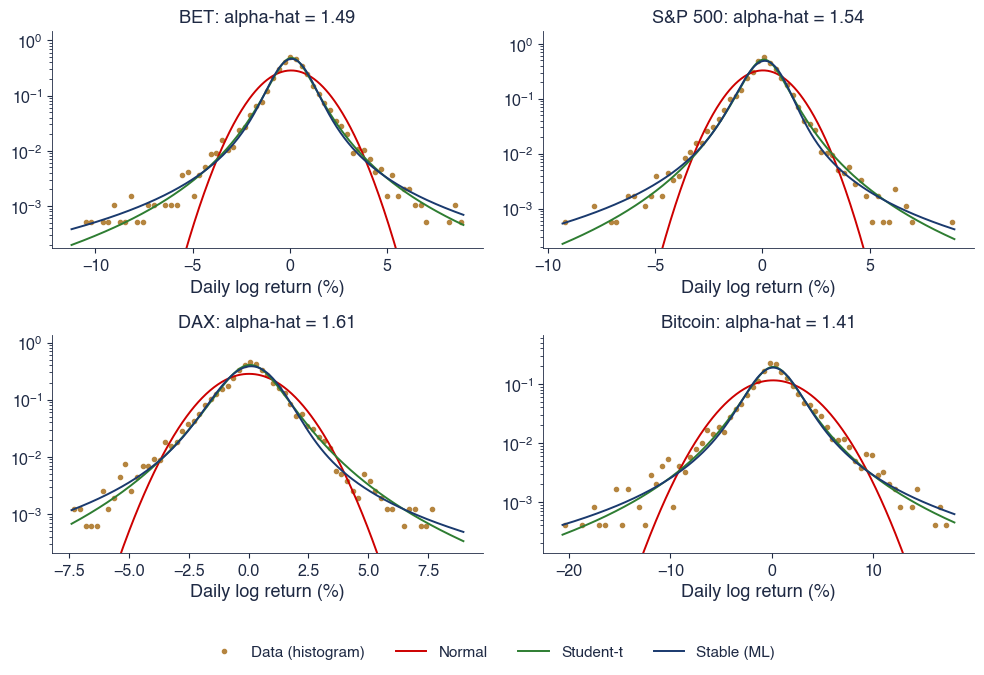

In [25]:
fig_fit_density(fits, save=False)

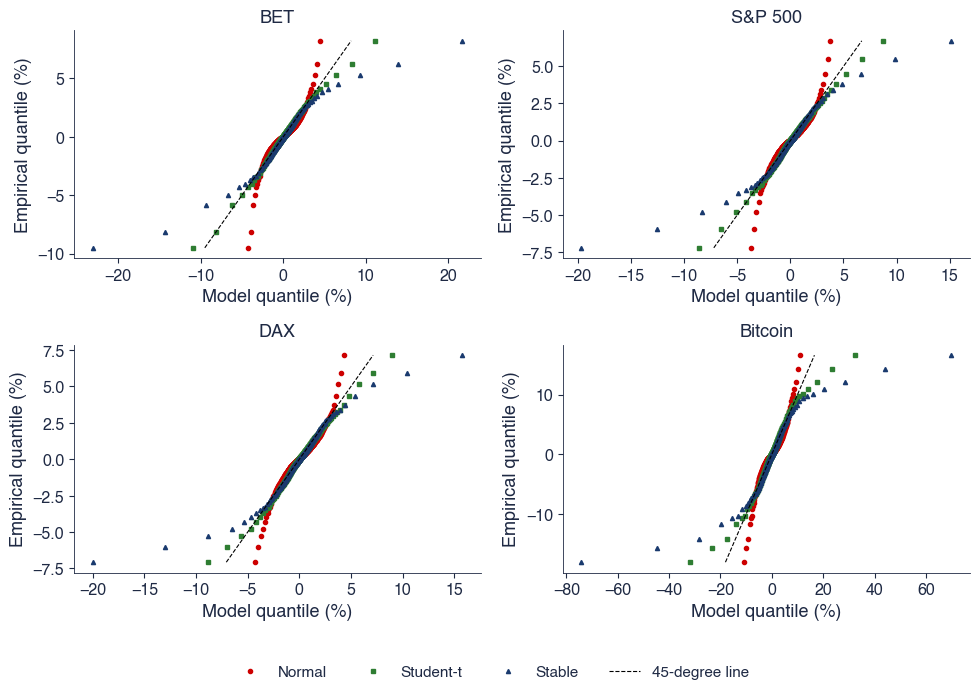

In [26]:
fig_qq_real(fits, save=False)

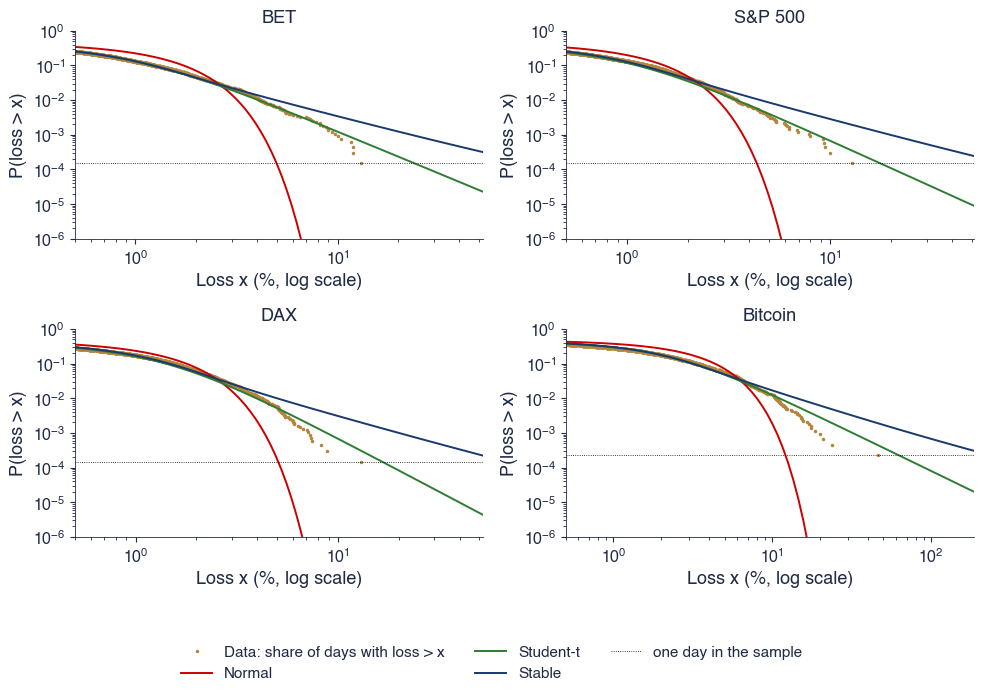

In [27]:
fig_tails_real(fits, save=False)

In [28]:
pd.DataFrame(tail_counts(fits)).round(2)

,bet,sp500,dax,btc
n,6670.00,6714.00,6786.00,4384.00
obs_3,149.00,104.00,171.00,512.00
Normal_3,94.93,42.44,108.34,813.05
Student-t_3,129.05,94.55,139.82,479.01
Stable_3,148.14,134.43,175.33,468.64
obs_5,42.00,23.00,40.00,254.00
Normal_5,0.98,0.12,1.23,311.09
Student-t_5,41.50,26.98,35.46,211.00
Stable_5,65.52,57.32,68.05,214.99
obs_7,20.00,7.00,8.00,113.00


## 7. The critique: does α stay the same when returns are summed?

- Under i.i.d. stable returns, weekly and monthly sums keep the same α.
- The running sample variance of the S&P 500 against paths simulated from its fitted stable law.

In [29]:
def aggregation_alpha(names=ASSETS):
    """ML alpha-hat (with standard error) for daily, weekly and monthly log returns of each series."""
    out = {}
    for k in names:
        r = returns(k)
        out[k] = {}
        for lab, x in [('daily', r), ('weekly', aggregate(r, 'W')), ('monthly', aggregate(r, 'ME'))]:
            s = stable_mle(x.values)
            m = mcculloch(x.values)
            edge = s['alpha'] >= 1.998                       # estimate at the upper bound alpha = 2 (Normal)
            out[k][lab] = {'n': len(x), 'alpha': 2.0 if edge else s['alpha'], 'se': float('nan') if edge else s['se_alpha'],
                           'beta': s['beta'], 'alpha_mcc': m['alpha'], 'at_bound': bool(edge)}
    return out


def fig_aggregation(agg, save=True):
    """alpha-hat (ML, 95% intervals) by return horizon: a stable i.i.d. series would keep the same alpha."""
    fig, ax = plt.subplots(figsize=(10, 4.0))
    hs = ['daily', 'weekly', 'monthly']
    for j, k in enumerate(agg):
        xs = np.arange(3) + (j - 1.5) * 0.08
        a = [agg[k][h]['alpha'] for h in hs]
        e = [1.96 * agg[k][h]['se'] for h in hs]
        ax.errorbar(xs, a, yerr=e, fmt='o-', color=COLORS[k], capsize=3, label=LABELS[k])
    ax.axhline(2, color='black', lw=0.8, ls='--', label='alpha = 2 (Normal)')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Daily', 'Weekly', 'Monthly'])
    ax.set_ylabel('alpha-hat (ML, 95% interval)')
    st.legend_outside_bottom(ax, ncol=5, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_aggregation')


def fig_running_var_real(fits, k='sp500', paths=3, save=True):
    """Running sample variance of the S&P 500 daily log returns vs paths simulated from the fitted stable law."""
    r = returns(k)
    s = fits[k]['stable']
    n = len(r)
    i = np.arange(1, n + 1)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    rng = np.random.default_rng(SEED)
    out = {}
    for j, c in zip(range(paths), ['#CD0000', '#E67E22', '#2E7D32']):
        x = rstable(n, s['alpha'], s['beta'], s['gamma'], s['delta0'], param=0, rng=rng)
        v = np.cumsum((x - x.mean()) ** 2) / i
        ax.plot(r.index[19:], v[19:], color=c, lw=1.0, label=f'simulated from the fitted stable law, path {j + 1}')
        out[f'sim{j + 1}'] = float(v[-1])
    v = (np.cumsum(r.values ** 2) / i - (np.cumsum(r.values) / i) ** 2)
    ax.plot(r.index[19:], v[19:], color='#1A3A6E', lw=2.0, label=f'{LABELS[k]} daily log returns (%)')
    ax.set_yscale('log')
    ax.set_ylabel('Running sample variance (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch3_running_var_real')
    out['data'] = float(v[-1])
    out['data_2010'] = float(v[np.searchsorted(r.index, pd.Timestamp('2010-01-01'))])
    return out

In [30]:
agg = aggregation_alpha()
pd.DataFrame({(k, h): v for k, a in agg.items() for h, v in a.items()}).T.round(3)

n     alpha        se      beta alpha_mcc at_bound
bet   daily    6670  1.485717  0.019825 -0.015725  1.413952    False
      weekly   1380  1.564371  0.045614   0.00622  1.436306    False
      monthly   321  1.499758   0.08535 -0.226031  1.426442    False
sp500 daily    6714  1.540402  0.020947 -0.180995  1.437528    False
      weekly   1394  1.641777  0.044908 -0.268295  1.536934    False
      monthly   321  1.819443  0.063847    -0.999  1.507605    False
dax   daily    6786  1.605672  0.021377 -0.179026  1.455004    False
      weekly   1394  1.718973  0.042275 -0.417715  1.652667    False
      monthly   321  1.693853  0.086021 -0.594181  1.583938    False
btc   daily    4384  1.409513  0.025927  0.019114  1.322178    False
      weekly    627  1.670586  0.087947 -0.083087  1.397719    False
      monthly   145       2.0       NaN  0.252127  1.847083     True

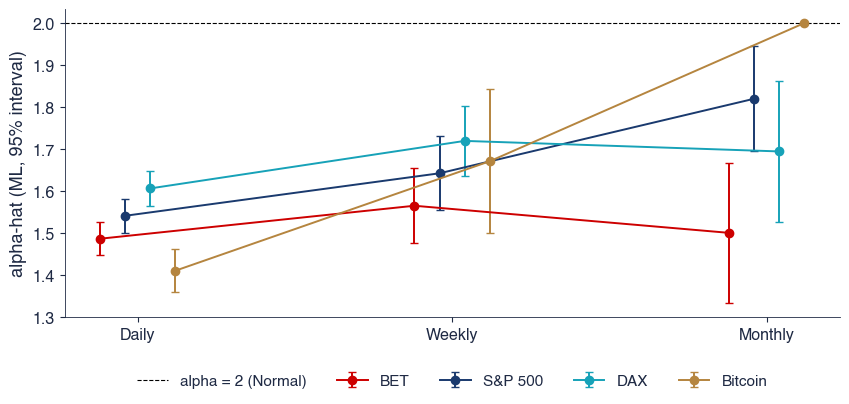

In [31]:
fig_aggregation(agg, save=False)

{'sim1': 5.851661717398997,
 'sim2': 5.411630275808486,
 'sim3': 15.629630649437338,
 'data': 1.4712216262637645,
 'data_2010': 1.963110067457769}

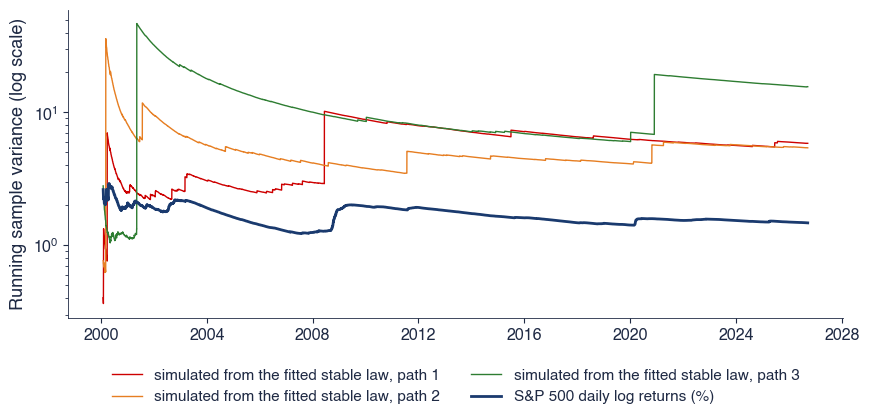

In [32]:
fig_running_var_real(fits, save=False)

## 8. AI for scientific discovery: have the tails of Bitcoin become lighter?

- Open question: is the tail of Bitcoin returns lighter now than in its first years?
- Starter code: the McCulloch α of Bitcoin daily log returns for each calendar year, with bootstrap intervals.
- Check before trusting any answer, yours or an AI's: the parameterisation (S0 or S1), the units, the window length, and whether the change survives returns divided by a rolling volatility.

In [33]:
r = returns('btc')
rng = np.random.default_rng(SEED)
rows = {}
for y, x in r.groupby(r.index.year):
    if len(x) < 300:
        continue
    a = mcculloch(x.values)['alpha']
    bs = [mcculloch(rng.choice(x.values, len(x)))['alpha'] for _ in range(300)]
    rows[y] = {'n': len(x), 'alpha': a, 'lo': np.percentile(bs, 2.5), 'hi': np.percentile(bs, 97.5)}
pd.DataFrame(rows).T.round(3)

,n,alpha,lo,hi
2015,365.0,1.363,1.167,1.530
2016,366.0,1.198,1.051,1.248
2017,365.0,1.448,1.258,1.665
2018,365.0,1.301,1.135,1.550
2019,365.0,1.293,1.169,1.518
2020,366.0,1.350,1.171,1.545
2021,365.0,1.590,1.398,1.754
2022,365.0,1.378,1.246,1.608
2023,365.0,1.336,1.175,1.494
2024,366.0,1.486,1.327,1.692
